In [4]:
import pandas as pd

df = pd.read_pickle('../data/clean/MachineLearning_Clean.pkl')

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, r2_score
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression


In [6]:
label_cols = [
    'make',
    'Model',
    'MainCrestaZone',
    'SubCrestaZone'
]
category_cols = [
    'LegalType',
    'Title',
    'Bank',
    'AccountType',
    'MaritalStatus',
    'Gender',
    'Country',
    'Province',
    'VehicleType',
    'CoverCategory',
    'CoverType',
    'Product',
    'StatutoryClass',
    'StatutoryRiskType'
]
bool_cols = ['AlarmImmobiliser', 'TrackingDevice', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted']

object_cols = ['Citizenship', 'Language', 'ItemType', 'bodytype', 
               'TermFrequency', 'ExcessSelected', 'CoverGroup', 'Section']


In [7]:
df_encoded = pd.get_dummies(df, columns=category_cols, drop_first=True)

In [8]:
for col in label_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [9]:
for col in bool_cols:
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0}).fillna(0)

In [10]:
df_encoded['TransactionMonth'] = pd.to_datetime(df_encoded['TransactionMonth'], errors='coerce')
df_encoded['TransactionMonth'] = df_encoded['TransactionMonth'].astype('int64') // 10**9

df_encoded['VehicleIntroDate'] = pd.to_datetime(df_encoded['VehicleIntroDate'], errors='coerce')
df_encoded['VehicleIntroDate'] = df_encoded['VehicleIntroDate'].astype('int64') // 10**9

C:\Users\ruthg\AppData\Local\Temp\ipykernel_24428\912423016.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_encoded['VehicleIntroDate'] = pd.to_datetime(df_encoded['VehicleIntroDate'], errors='coerce')


In [11]:
df_encoded = df_encoded.drop(['UnderwrittenCoverID', 'PolicyID'], axis=1)

In [12]:
df_sev = df_encoded[df_encoded['TotalClaims'] > 0].copy()

x = df_sev.drop('TotalClaims', axis=1)
y = df_sev['TotalClaims']

x_train_sev, x_test_sev, y_train_sev, y_test_sev = train_test_split(x, y, test_size=0.3, random_state=42)

In [13]:
for col in object_cols:
    x_train_sev[col] = x_train_sev[col].replace(r'^\s*$', 'Unknown', regex=True)
    x_test_sev[col] = x_test_sev[col].replace(r'^\s*$', 'Unknown', regex=True)
    le = LabelEncoder()
    x_train_sev[col] = le.fit_transform(x_train_sev[col].astype(str))
    x_test_sev[col] = x_test_sev[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

xgb_sev = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_sev.fit(x_train_sev, y_train_sev)
y_pred_sev = xgb_sev.predict(x_test_sev)
rmse = np.sqrt(mean_squared_error(y_test_sev, y_pred_sev))
r2 = r2_score(y_test_sev, y_pred_sev)
print('Severity rmse:', rmse)
print('Severity r2:', r2)


Severity rmse: 13107.62290098373
Severity r2: 0.8908835316583134


In [14]:

df_encoded['HasClaim'] = (df_encoded['TotalClaims'] > 0).astype(int)
x = df_encoded.drop(['TotalClaims', 'HasClaim'], axis=1)
y = df_encoded['HasClaim']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [15]:
object_cols = x_train.select_dtypes(include='object').columns.tolist()
for col in object_cols:
    x_train[col] = x_train[col].replace(r'^\s*$', 'Unknown', regex=True)
    x_test[col] = x_test[col].replace(r'^\s*$', 'Unknown', regex=True)
    le = LabelEncoder()
    x_train[col] = le.fit_transform(x_train[col].astype(str))
    x_test[col] = x_test[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

for col in bool_cols:
    if col in x_train.columns:
        x_train[col] = x_train[col].map({'Yes':1,'No':0}).fillna(0)
        x_test[col] = x_test[col].map({'Yes':1,'No':0}).fillna(0)


high_card_cols = ['PostalCode', 'Model']
x_train = x_train.drop(columns=[c for c in high_card_cols if c in x_train.columns])
x_test = x_test.drop(columns=[c for c in high_card_cols if c in x_test.columns])

clf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)
y_pred_prob = clf.predict_proba(x_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

Accuracy: 0.9998233509982335
Precision: 0.9859484777517564
Recall: 0.9535673839184597
F1-Score: 0.9694876223373633
ROC-AUC: 0.9794270554122668


c:\Users\ruthg\OneDrive\Desktop\AlphaCare-Week3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


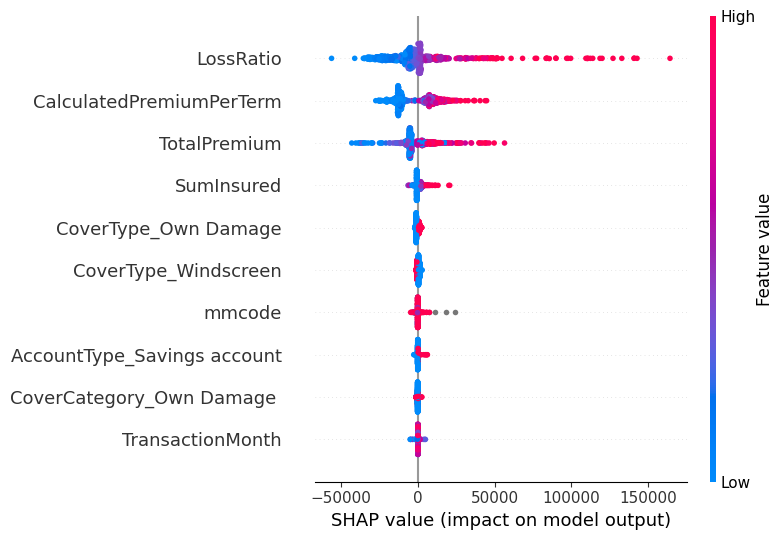

In [ ]:
import shap
explainer = shap.Explainer(xgb_sev)
shap_val = explainer(x_test_sev)

shap.summary_plot(shap_val, x_test_sev, max_display=10)

In [18]:
expense_loading = df_encoded['CalculatedPremiumPerTerm'].mean()
profit_margin = 0.1
y_pred_prob_aligned = y_pred_prob[:len(y_pred_sev)]  # simple alignment if order matches

risk_based_premium = (y_pred_prob_aligned * y_pred_sev) + expense_loading
risk_based_premium = risk_based_premium * (1 + profit_margin)

df_premiums = pd.DataFrame({
 'Pred_Prob_Claim': y_pred_prob_aligned,
    'Pred_Severity': y_pred_sev,
    'Expense_Loading': expense_loading,
    'Profit_Margin': profit_margin,
    'Risk_Based_Premium': risk_based_premium
})

print(df_premiums.head())

   Pred_Prob_Claim  Pred_Severity  Expense_Loading  Profit_Margin  \
0              0.0    1049.988892       117.875691            0.1   
1              0.0    6131.823242       117.875691            0.1   
2              0.0   52850.527344       117.875691            0.1   
3              0.0    2135.837158       117.875691            0.1   
4              0.0    1187.906982       117.875691            0.1   

   Risk_Based_Premium  
0           129.66326  
1           129.66326  
2           129.66326  
3           129.66326  
4           129.66326  


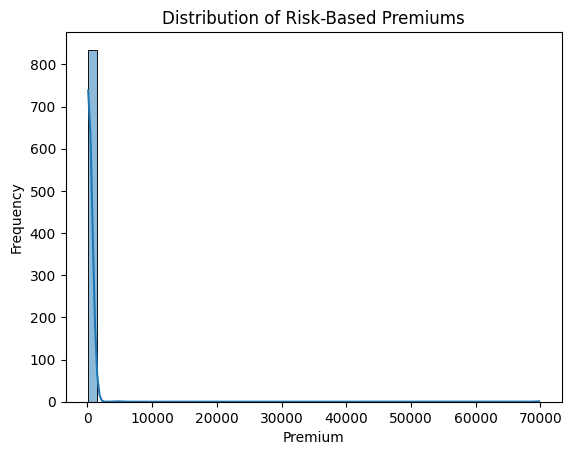

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df_premiums['Risk_Based_Premium'], bins=50, kde=True)
plt.title("Distribution of Risk-Based Premiums")
plt.xlabel("Premium")
plt.ylabel("Frequency")
plt.show()


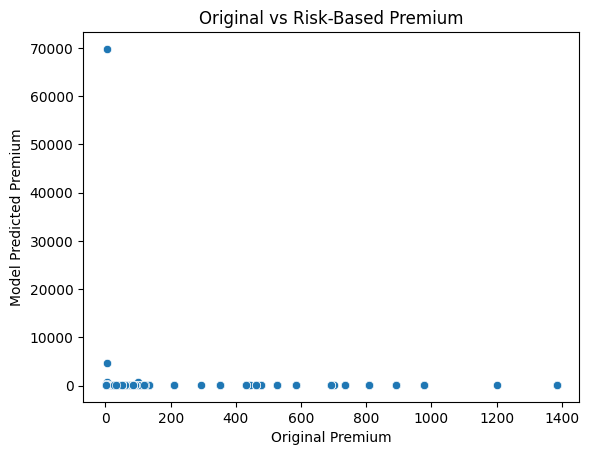

In [20]:
sns.scatterplot(x=df_encoded['CalculatedPremiumPerTerm'][:len(risk_based_premium)],
                y=risk_based_premium)
plt.xlabel("Original Premium")
plt.ylabel("Model Predicted Premium")
plt.title("Original vs Risk-Based Premium")
plt.show()
